In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rishabhdevadiga/titanic-dataset/train.csv
/kaggle/input/datasets/rishabhdevadiga/titanic-dataset/test.csv


# Import Libraries :

In [63]:
import numpy as np # linear algebra
import pandas as pd 
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# pre-processing
from sklearn.compose import ColumnTransformer
# Imputation
from sklearn.impute import SimpleImputer
# Pipeline
from sklearn.pipeline import Pipeline
# Categorical Columns
from sklearn.preprocessing import OneHotEncoder
# Scaling
from sklearn.preprocessing import StandardScaler
# train-test-split
from sklearn.model_selection import train_test_split
# Logistic regression
from sklearn.linear_model import LogisticRegression
# Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
#Random Forest
from sklearn.ensemble import RandomForestClassifier
# K Nearest Neigbours 
from sklearn.neighbors import KNeighborsClassifier

In [3]:
train_set = pd.read_csv("/kaggle/input/datasets/rishabhdevadiga/titanic-dataset/train.csv")
test_set = pd.read_csv("/kaggle/input/datasets/rishabhdevadiga/titanic-dataset/test.csv")

# Data Inspection :

In [4]:
train_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train_set.shape

(891, 12)

In [6]:
train_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
train_set.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

# Exploratory Data Analysis :

In [8]:
train_set.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
test_set.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [10]:
train_set['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

- 549 - Non Survived
- 342 - Survived

## Pclass :

In [11]:
#print percentage of people who survived by pclass
print("Percentage of Pclass = 1 who survived:", train_set['Survived'][train_set
      ['Pclass'] == 1].value_counts(normalize = True)[1] * 100)

print("Percentage of Pclass = 2 who survived:", train_set['Survived'][train_set
      ['Pclass'] == 2].value_counts(normalize = True)[1] * 100)

print("Percentage of Pclass = 3 who survived:", train_set['Survived'][train_set
      ['Pclass'] == 3].value_counts(normalize = True)[1] * 100)

Percentage of Pclass = 1 who survived: 62.96296296296296
Percentage of Pclass = 2 who survived: 47.28260869565217
Percentage of Pclass = 3 who survived: 24.236252545824847


<Axes: xlabel='Survived', ylabel='count'>

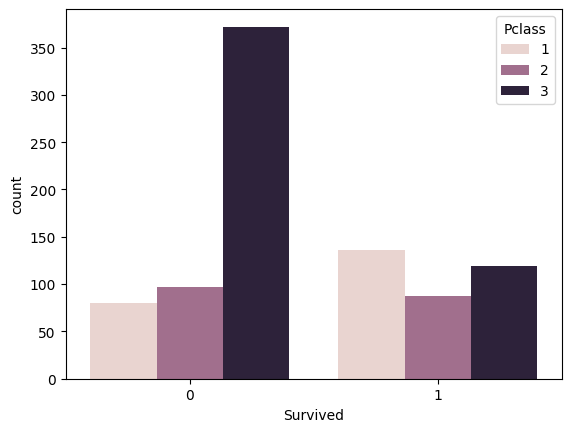

In [12]:
sns.countplot(data = train_set, x = "Survived", hue = "Pclass")

## Gender :

Count of females who survived: 233
Count of females who did not survive: 81
--------------------------------------------
Count of males who survived: 109
Count of males who did not survive: 468


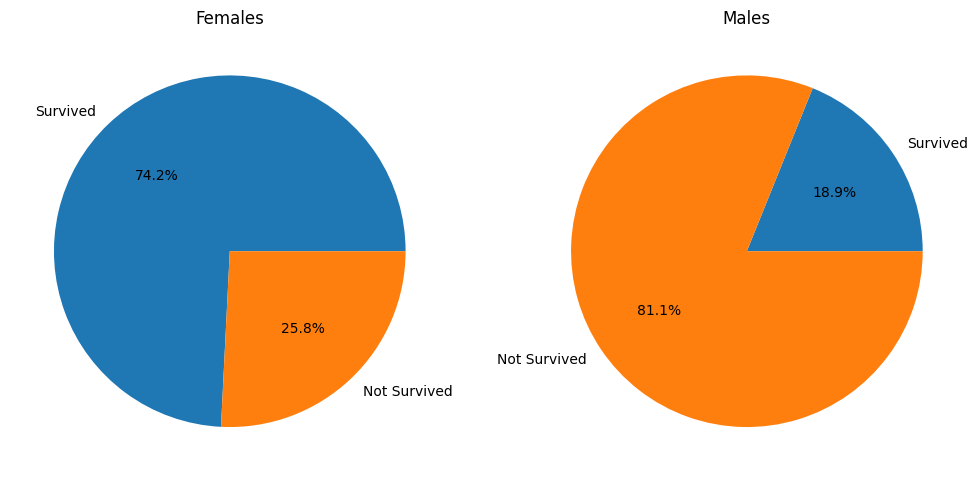

In [13]:
#Count of females who survived and who didnt

female_survived_count = train_set[(train_set['Sex'] == 'female') & (train_set['Survived'] == 1)].shape[0]
female_not_survived_count = train_set[(train_set['Sex'] == 'female') & (train_set['Survived'] == 0)].shape[0]

#Count of males who survived and who didnt
male_survived_count = train_set[(train_set['Sex'] == 'male') & (train_set['Survived'] == 1)].shape[0]
male_not_survived_count = train_set[(train_set['Sex'] == 'male') & (train_set['Survived'] == 0)].shape[0]

print("Count of females who survived:", female_survived_count)
print("Count of females who did not survive:", female_not_survived_count)
print("--------------------------------------------")
print("Count of males who survived:", male_survived_count)
print("Count of males who did not survive:", male_not_survived_count)

#Pie plot for females

plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
labels = ['Survived', 'Not Survived']
Sizes = [female_survived_count, female_not_survived_count]
plt.pie(Sizes, labels=labels, autopct = '%1.1f%%')
plt.title('Females')

#Pie plot for males

plt.subplot(1,2,2)
Sizes = [male_survived_count, male_not_survived_count]
plt.pie(Sizes, labels=labels, autopct = '%1.1f%%')
plt.title('Males')

plt.tight_layout()
plt.show()

## Age Groups :

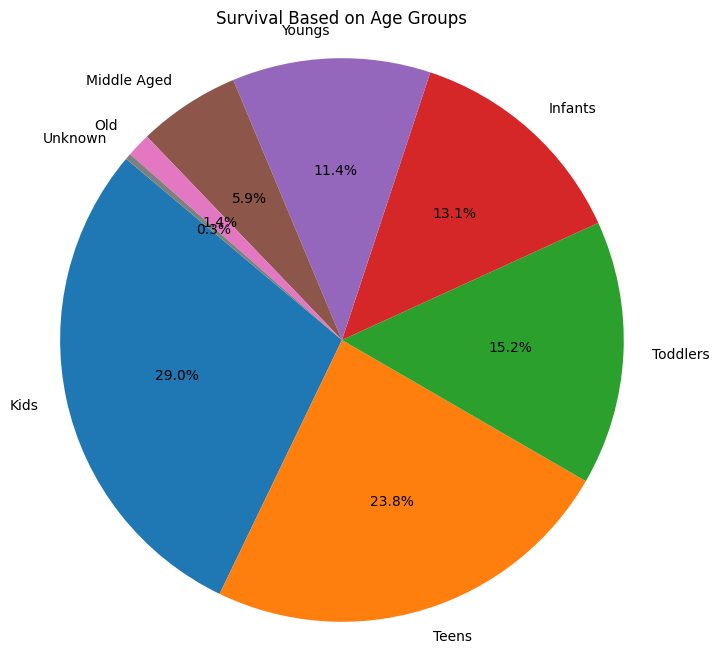

In [14]:
# Assuming train_set contains the necessary data

# Define age groups
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ['Infants', 'Toddlers', 'Kids', 'Teens', 'Youngs', 'Middle Aged', 'Old', 'Unknown']  # Add 'Unknown' for values outside the defined bins
# Categorize ages into groups
train_set['AgeGroup'] = pd.cut(train_set['Age'], bins=age_bins, labels=age_labels)

# Count survivors in each age group
survivors_by_age_group = train_set[train_set['Survived'] == 1]['AgeGroup'].value_counts()
# test data
# Define age groups
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ['Infants', 'Toddlers', 'Kids', 'Teens', 'Youngs', 'Middle Aged', 'Old', 'Unknown']  # Add 'Unknown' for values outside the defined bins
# Categorize ages into groups
test_set['AgeGroup'] = pd.cut(test_set['Age'], bins=age_bins, labels=age_labels)

# Count survivors in each age group
survivors_by_age_group = train_set[train_set['Survived'] == 1]['AgeGroup'].value_counts()

# Plot
plt.figure(figsize=(8, 8))
plt.pie(survivors_by_age_group, labels=survivors_by_age_group.index, autopct='%1.1f%%', startangle=140)
plt.title('Survival Based on Age Groups')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## SibSp :

In [15]:
train_set['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Percentage of SibSp = 0 who survived:  34.53947368421053
Percentage of SibSp = 1 who survived:  53.588516746411486
Percentage of SibSp = 2 who survived:  46.42857142857143
Percentage of SibSp = 3 who survived:  25.0
Percentage of SibSp = 4 who survived:  16.666666666666664


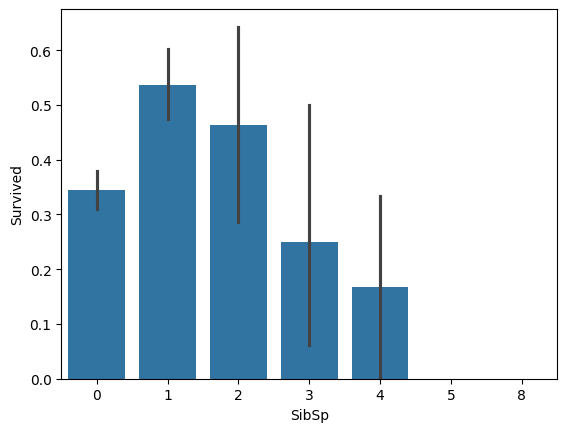

In [16]:
sns.barplot(x = 'SibSp', y = 'Survived', data = train_set)

for i in range(5):
    print(f"Percentage of SibSp = {i} who survived: ", train_set['Survived'][train_set['SibSp'] == i].value_counts(normalize = True)[1]*100)

- people with more siblings or spouses aboard were less likely to survive.

## Embarked :

<Figure size 800x600 with 0 Axes>

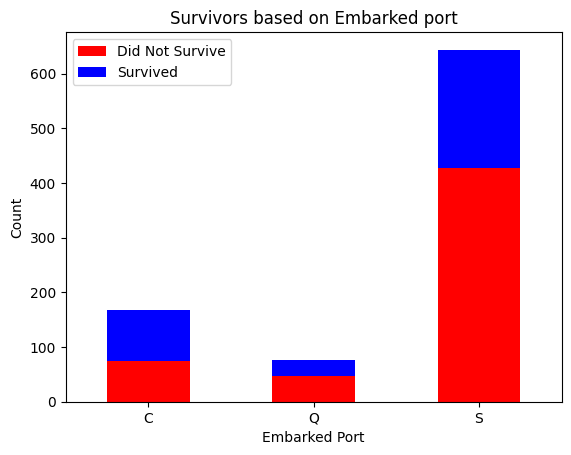

In [17]:
# Grouping data by 'Embarked' and 'Survived', and calculating the count of passengers
survivors_by_embarked = train_set.groupby(['Embarked', 'Survived']).size().unstack()

# Plot
plt.figure(figsize = (8,6))
survivors_by_embarked.plot(kind = 'bar', stacked = 'True', color = ['red', 'blue'])
plt.title('Survivors based on Embarked port')
plt.xlabel('Embarked Port')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.legend(['Did Not Survive', 'Survived'], loc = 'upper left')
plt.show()

In [18]:
# Assuming df_train contains the necessary data

# Count survivors based on embarked port
survived_by_embarked = train_set[train_set['Survived'] == 1]['Embarked'].value_counts()
print("Survived based on embarked port:")
print(survived_by_embarked)
print("-------------------------------------")
# Count non-survivors based on embarked port
non_survived_by_embarked = train_set[train_set['Survived'] == 0]['Embarked'].value_counts()
print("Non Survived based on embarked port:")
print(non_survived_by_embarked)

Survived based on embarked port:
Embarked
S    217
C     93
Q     30
Name: count, dtype: int64
-------------------------------------
Non Survived based on embarked port:
Embarked
S    427
C     75
Q     47
Name: count, dtype: int64


- Mostly people survived of S = Southampton
- MOstly people non survived also S = Southampton 

## Fare :

In [19]:
# scatter plot age and fare base on survived in plotly
fig = px.scatter(train_set, x = 'Age', y = 'Fare', color = 'Survived', title = 'Age vs Fare')
fig.show()

## Parch :

In [20]:
train_set['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

Percentage of Parch = 0 who survived:  34.365781710914455
Percentage of Parch = 1 who survived:  55.08474576271186
Percentage of Parch = 2 who survived:  50.0
Percentage of Parch = 3 who survived:  60.0


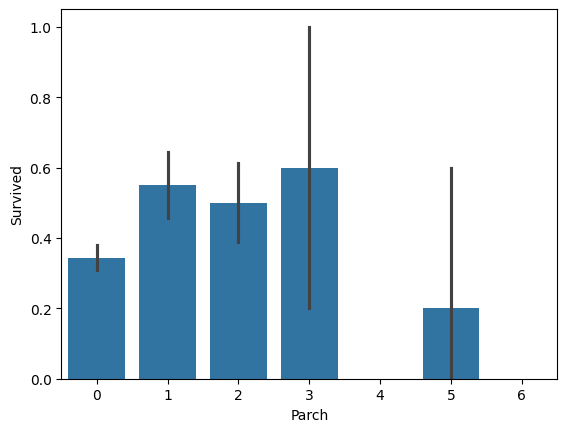

In [21]:
sns.barplot(x = 'Parch', y = 'Survived', data = train_set)

for i in range(4):
    print(f"Percentage of Parch = {i} who survived: ", train_set['Survived'][train_set['Parch'] == i].value_counts(normalize = True)[1]*100)

## FamilySize : (Engineered Feature)

In [22]:
train_set['FamilySize'] = train_set['SibSp'] + train_set['Parch'] + 1
test_set['FamilySize'] = test_set['SibSp'] + test_set['Parch'] + 1

In [23]:
print(train_set['FamilySize'].value_counts().sort_index())

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


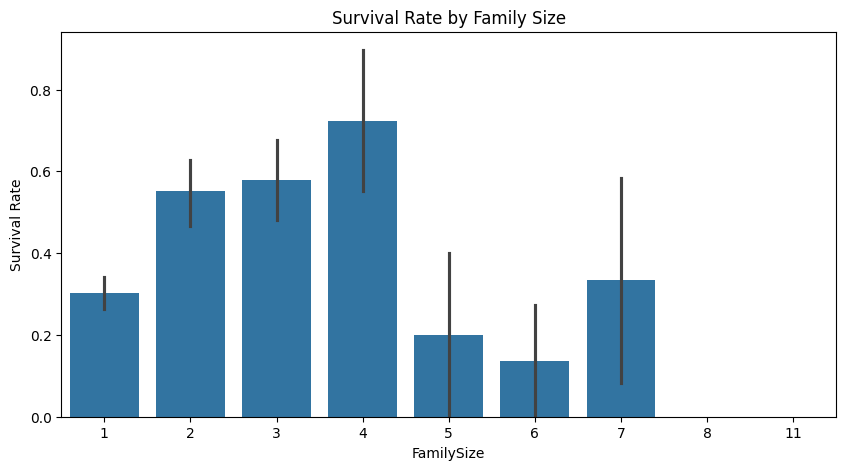

In [24]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=train_set,
    x="FamilySize",
    y="Survived",
    errorbar=("ci", 95)
)

plt.title("Survival Rate by Family Size")
plt.ylabel("Survival Rate")
plt.show()

## IsAlone : (Engineered Feature)

In [25]:
train_set['IsAlone'] = (train_set['FamilySize'] == 1).astype(int)
test_set['IsAlone'] = (test_set['FamilySize'] == 1).astype(int)

In [26]:
print(train_set['IsAlone']. value_counts())

IsAlone
1    537
0    354
Name: count, dtype: int64


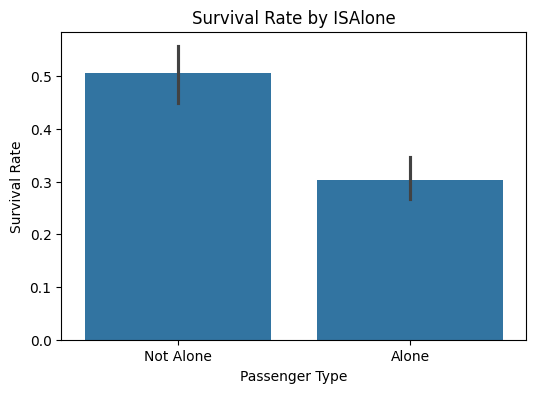

In [27]:
plt.figure(figsize = (6,4))

sns.barplot(
    data = train_set,
    x = 'IsAlone',
    y = 'Survived'
)

plt.xticks([0,1],['Not Alone', 'Alone'])
plt.title('Survival Rate by ISAlone')
plt.xlabel('Passenger Type')
plt.ylabel('Survival Rate')

plt.show()

# Check Missing Values :

<Axes: >

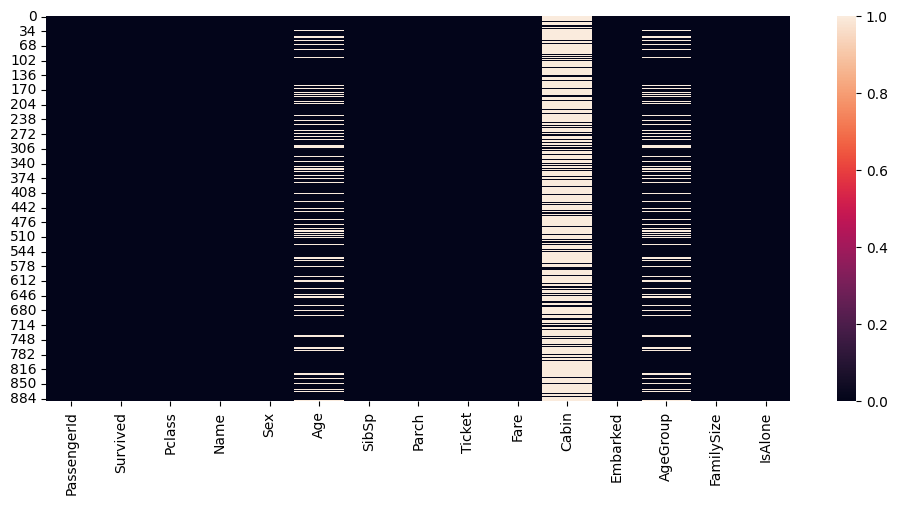

In [28]:
# check null values of train data by graphically
plt.figure(figsize=(12,5))
sns.heatmap(train_set.isnull())

<Axes: >

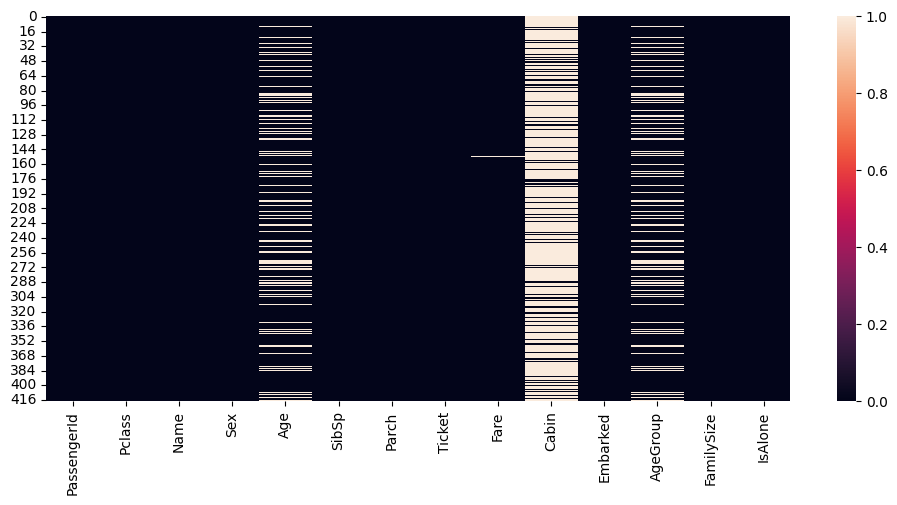

In [29]:
# check null values of test data by graphically
plt.figure(figsize=(12,5))
sns.heatmap(test_set.isnull())

In [30]:
train_set.isnull().sum().sort_values(ascending = False)

Cabin          687
AgeGroup       177
Age            177
Embarked         2
Pclass           0
Survived         0
PassengerId      0
SibSp            0
Sex              0
Name             0
Parch            0
Fare             0
Ticket           0
FamilySize       0
IsAlone          0
dtype: int64

In [31]:
# check null values in test data by using pandas
test_set.isnull().sum().sort_values(ascending=False)

Cabin          327
Age             86
AgeGroup        86
Fare             1
Pclass           0
PassengerId      0
SibSp            0
Sex              0
Name             0
Ticket           0
Parch            0
Embarked         0
FamilySize       0
IsAlone          0
dtype: int64

In [32]:
# percentage of null values in train set
percentage = (train_set.isnull().sum().sort_values(ascending = False)) / len(train_set) * 100
print(percentage)

Cabin          77.104377
AgeGroup       19.865320
Age            19.865320
Embarked        0.224467
Pclass          0.000000
Survived        0.000000
PassengerId     0.000000
SibSp           0.000000
Sex             0.000000
Name            0.000000
Parch           0.000000
Fare            0.000000
Ticket          0.000000
FamilySize      0.000000
IsAlone         0.000000
dtype: float64


In [33]:
# percentage of null values in test set
percentage = (test_set.isnull().sum().sort_values(ascending = False)) / len(test_set) * 100
print(percentage)

Cabin          78.229665
Age            20.574163
AgeGroup       20.574163
Fare            0.239234
Pclass          0.000000
PassengerId     0.000000
SibSp           0.000000
Sex             0.000000
Name            0.000000
Ticket          0.000000
Parch           0.000000
Embarked        0.000000
FamilySize      0.000000
IsAlone         0.000000
dtype: float64


# Impute Missing Values :

In [34]:
missing_data_cols = train_set.isnull().sum()[train_set.isnull().sum() > 0].index.tolist()
print("Columns  of missing values in train data :",missing_data_cols)

Columns  of missing values in train data : ['Age', 'Cabin', 'Embarked', 'AgeGroup']


In [35]:
# Cabin column  in train data have highest missing values so removed
train_set.drop('Cabin', axis=1, inplace = True)

- Cabin has more than 50% missing values in train data so removed from data

In [36]:
# Define Features
categorical_features = ['Embarked', 'AgeGroup','Sex']
numeric_features = ['Age', 'Pclass', 'SibSp', 'Fare', 'FamilySize', 'IsAlone']

In [37]:
# Create Transformers

numeric_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('OneHot', OneHotEncoder(handle_unknown = 'ignore'))
])

In [38]:
# Combine Transformer into a single preprocessor

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Train_Test_Split :

In [39]:
X = train_set.drop('Survived', axis=1)
y = train_set['Survived']

In [40]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# Logistic Regression :

In [41]:
model = Pipeline( steps = [
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter = 1000))
])

In [42]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Pclass', 'SibSp',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('OneHot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'AgeGroup',
                                                   'Sex'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [43]:
y_pred = model.predict(X_val)

In [44]:
accuracy = accuracy_score(y_val, y_pred)
print(f'Accuracy : {accuracy :4f}')

Accuracy : 0.815642


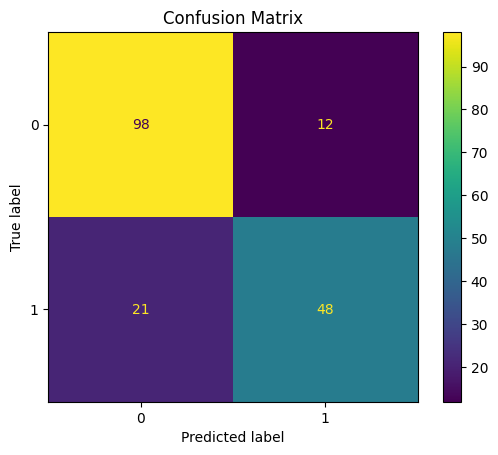

In [45]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
plt.title("Confusion Matrix")
plt.show()

In [46]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



In [47]:
y_prob = model.predict_proba(X_val)[:,1]
roc = roc_auc_score(y_val, y_prob)
print(f"ROC-AUC score: {roc:.4f}")

ROC-AUC score: 0.8494


# Decision Tree :

In [48]:
decision_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state = 42))
])

In [49]:
decision_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Pclass', 'SibSp',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('OneHot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'AgeGroup',
                                                   'Sex'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [50]:
dt_pred = decision_tree.predict(X_val)

In [51]:
dt_accuracy = accuracy_score(y_val, dt_pred)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.7821


In [52]:
print(classification_report(y_val, dt_pred))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       110
           1       0.71      0.74      0.72        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [53]:
y_prob = decision_tree.predict_proba(X_val)[:,1]
dt_roc = roc_auc_score(y_val, y_prob)
print(f"ROC-AUC score: {roc:.4f}")

ROC-AUC score: 0.8494


# Random Forest :

In [54]:
random_forest = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators = 100,
        random_state = 42
    ))
])

In [55]:
random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Pclass', 'SibSp',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('OneHot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'AgeGroup',
                                                   'Sex'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [56]:
rf_pred = random_forest.predict(X_val)

In [57]:
rf_accuracy = accuracy_score(y_val, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.7989


In [58]:
print(classification_report(y_val, rf_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



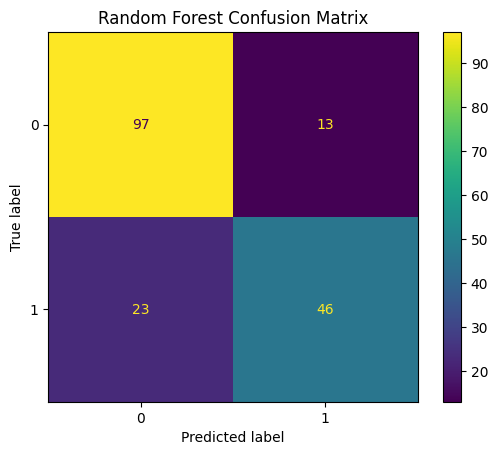

In [59]:
ConfusionMatrixDisplay.from_predictions(y_val, rf_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [60]:
comparison = pd.DataFrame({
    "Model" : [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy" : [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison.sort_values(by = "Accuracy", ascending = False)

,Model,Accuracy
0,Logistic Regression,0.815642
2,Random Forest,0.798883
1,Decision Tree,0.782123


# K nearest Neighbours (KNN) :

In [64]:
knn = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors = 5))
])

In [65]:
knn.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Pclass', 'SibSp',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('OneHot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'AgeGroup',
                                                   'Sex'])])),
                ('classifier', KNeighborsClassifier())])

In [67]:
knn_pred = knn.predict(X_val)

In [69]:
knn_accuracy = accuracy_score(y_val, knn_pred)
print(f'KNN Accuracy : {knn_accuracy:.4f}')

KNN Accuracy : 0.7877


In [70]:
print(classification_report(y_val, knn_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       110
           1       0.74      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179

